**Author**: Felipe Matheus  
**Start Date**: 23/07/2026  
**End Date**: 24/07/2026  
**Related Links**:

- Results so far: https://docs.google.com/spreadsheets/d/1OnIWY_bKxgdGU3trECDTL971WfXFPWgbW-dQzgP6KhI/edit?gid=0#gid=0
- Dataset used: https://drive.google.com/drive/u/0/folders/1VsU-taxtwfmDLUu5Z4JmdgXSoxUoB8FI

**Objective**

Build an uncertainty-aware probabilistic predictor of conductivity (IACS) after the **annealing** process, using AutoGluon. The output of every prediction is a Gaussian-like predictive distribution $\mathcal{N}(\hat\mu, \hat\sigma^2)$ where the variance is decomposed into epistemic and aleatoric components.

**Pipeline**

1. Setup and global configuration.
2. Load + preprocess data.
3. Train **Model A** (mean predictor with internal K-fold bagging).
4. Extract OOF predictions per base learner.
5. Recover ensemble weights via NNLS; compute weighted $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$.
6. Build aleatoric targets $\tilde r^2 = \max(r^2_{\text{OOF}} - \hat\sigma^2_{\text{epist}}, 0)$.
7. Train **Model B** on $\log(\tilde r^2 + \epsilon)$.
8. Calibration diagnostics and scalar recalibration.

# 1. Setup

In [1]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy.stats import norm
from autogluon.tabular import TabularPredictor


module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.modeling.Modeling import Modeling
from src.metrics.Evaluation import Evaluation
from src.DataLoader import LoaderHelper

from config.Variables import Variables

%load_ext autoreload
%autoreload 2

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Helper instances reused across the notebook.
proc = Processing()
feng = FeatureEngineering()
modl = Modeling()
evla = Evaluation()
varv = Variables()
load = LoaderHelper()


## 1.1 Global configuration

All knobs that may change between surrogates / processes / experiments live here. Other notebooks for other surrogates only need to edit this cell.

In [3]:
# ---- Experiment settings ----
TAG = "only-essays-v2-best-quality"
SCHEMA_DATE = "230726"

# ---- Paths ----
FILE_NAME = "dataset_annealing_iacs.csv"
FILE_NAME_SCHEMA_DATA = "schema_annealing_essays_{}.csv".format(SCHEMA_DATE)
# FILE_NAME_VALIDATION_DATA = "Experimental Results Annealing V2 - CompiledResults.csv"

PROCESS = "annealing_elongation"

# All artifacts of THIS run (predictors included) live under the TAG folder,
# so different experiments never overwrite each other's models.
EXPERIMENT_DIR = os.path.join(varv.PATHS.models, PROCESS, TAG)
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

# ---- Dataset schema ----
TARGET = "elongation_final"
FEATURES = ["initial_diameter", "tensile_strength", "purity", "elongation", "temperature", "time"]
WEIGHT_ON_ESSAY_ROWS = 1

# ---- AutoGluon training knobs (Model A) ----
PRESETS_A = "best_quality"     # 'best_quality' for final runs only or medium_quality
NUM_BAG_FOLDS_A = 5               # K-fold bagging produces OOF preds
NUM_BAG_SETS_A = 1
NUM_STACK_LEVELS_A = 0            # no multi-level stacking; keep simple
TIME_LIMIT_A = 120

# ---- AutoGluon training knobs (Model B) ----
PRESETS_B = "medium_quality"
NUM_BAG_FOLDS_B = 5
NUM_STACK_LEVELS_B = 0
TIME_LIMIT_B = 60

# ---- Uncertainty pipeline knobs ----
USE_WEIGHTED_VARIANCE = True      # False = uniform mean/var (sanity check)
VARIANCE_FLOOR_FRAC = 0.01        # floor of sigma2_aleat as fraction of Var(y), in case of predictions as "100% sure" it still adds  small variance
CALIBRATION_ALPHAS = (0.5, 0.8, 0.9, 0.95)
RECALIBRATION_TARGET_ALPHA = 0.9

# ---- AGL x H2O comparison ----
USE_SHARED_FOLDS = False           # same fold_id column on both engines
FOLD_SEED = 42

# ---- Physical constraints (inference-time) ----
Y_MAX = 105.0                     # physical ceiling for %IACS


# 2. Data

## 2.1 Schema data

In [5]:
df, df_val = proc.process_annealing_elongation(
    features=FEATURES,
    target=TARGET,
    df_schema=pd.read_csv(os.path.join(varv.PATHS.data_raw, FILE_NAME_SCHEMA_DATA))
)

In [6]:
df

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final
0,2.160000,391.690000,99.9000,4.90,573.0,30.0,48.60
1,2.182333,387.595254,99.9000,6.02,573.0,30.0,56.21
2,1.200000,431.580000,99.9000,0.94,523.0,30.0,20.15
3,1.200000,431.580000,99.9000,0.94,523.0,60.0,22.04
4,1.200000,431.580000,99.9000,0.94,523.0,90.0,24.62
5,1.200000,431.580000,99.9000,0.94,573.0,30.0,24.72
6,1.200000,431.580000,99.9000,0.94,573.0,60.0,27.43
7,1.200000,431.580000,99.9000,0.94,573.0,90.0,25.24
8,1.200000,431.580000,99.9000,0.94,623.0,30.0,27.06
9,1.200000,431.580000,99.9000,0.94,623.0,60.0,26.17


## 2.2 Validation data

In [ ]:
# # ---- Validation data ----
# df_val = proc.load_validation_data_chimie_paris(
#     path=os.path.join(varv.PATHS.data_processed, FILE_NAME_VALIDATION_DATA)
# )


In [7]:
df_val

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final
9,1.20,431.58,99.9000,0.94,623.0,60.0,26.17
25,2.00,376.08,99.9558,5.33,573.0,30.0,8.55
8,1.20,431.58,99.9000,0.94,623.0,30.0,27.06
21,1.20,335.21,99.9800,1.61,523.0,30.0,51.01
0,2.16,391.69,99.9000,4.90,573.0,30.0,48.60
12,1.20,397.09,99.9000,2.36,573.0,30.0,44.18
17,1.20,397.09,99.9000,2.36,523.0,90.0,42.28
22,1.20,335.21,99.9800,1.61,523.0,60.0,49.42


# 3. Train Model A — Mean Predictor with Bagging

Model A is an AutoGluon ensemble trained with $K$-fold bagging internally. Bagging is non-optional: without it we cannot extract OOF predictions, which are required for honest residuals and for the epistemic-variance estimate.

In [13]:
df.head(10)

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final
0,2.160000,391.690000,99.9,4.90,573.0,30.0,48.60
1,2.182333,387.595254,99.9,6.02,573.0,30.0,56.21
2,1.200000,431.580000,99.9,0.94,523.0,30.0,20.15
3,1.200000,431.580000,99.9,0.94,523.0,60.0,22.04
4,1.200000,431.580000,99.9,0.94,523.0,90.0,24.62
5,1.200000,431.580000,99.9,0.94,573.0,30.0,24.72
6,1.200000,431.580000,99.9,0.94,573.0,60.0,27.43
7,1.200000,431.580000,99.9,0.94,573.0,90.0,25.24
8,1.200000,431.580000,99.9,0.94,623.0,30.0,27.06
9,1.200000,431.580000,99.9,0.94,623.0,60.0,26.17


In [8]:
df.head(10)

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final,is_essay,weight_col
0,2.160000,391.690000,99.9,4.90,573.0,30.0,48.60,True,1.0
1,2.182333,387.595254,99.9,6.02,573.0,30.0,56.21,True,1.0
2,1.200000,431.580000,99.9,0.94,523.0,30.0,20.15,True,1.0
3,1.200000,431.580000,99.9,0.94,523.0,60.0,22.04,True,1.0
4,1.200000,431.580000,99.9,0.94,523.0,90.0,24.62,True,1.0
5,1.200000,431.580000,99.9,0.94,573.0,30.0,24.72,True,1.0
6,1.200000,431.580000,99.9,0.94,573.0,60.0,27.43,True,1.0
7,1.200000,431.580000,99.9,0.94,573.0,90.0,25.24,True,1.0
8,1.200000,431.580000,99.9,0.94,623.0,30.0,27.06,True,1.0
9,1.200000,431.580000,99.9,0.94,623.0,60.0,26.17,True,1.0


In [12]:
predictor_a = modl.fit_model_a(
    df=df,
    target=TARGET,
    features=FEATURES,
    path=os.path.join(EXPERIMENT_DIR, "model_a"),
    presets=PRESETS_A,
    num_bag_folds=NUM_BAG_FOLDS_A,
    num_bag_sets=NUM_BAG_SETS_A,
    num_stack_levels=NUM_STACK_LEVELS_A,
    time_limit=TIME_LIMIT_A,
    # groups="fold_id" if USE_SHARED_FOLDS else None,
    # sample_weight="weight_col",
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       7.79 GB / 31.57 GB (24.7%)
Disk Space Avail:   739.04 GB / 932.08 GB (79.3%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=5, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_elongation\only-essays-v2-best-quality\model_a"
Train Data Rows:    28
Train Data Columns: 6
Label Column:       elongation_final
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-v

In [14]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-7.702562,root_mean_squared_error,0.021977,7.414273,0.000000,0.010575,2,True,17
1,NeuralNetTorch_r79_BAG_L1,-7.702562,root_mean_squared_error,0.021977,7.403698,0.021977,7.403698,1,True,11
2,NeuralNetTorch_r22_BAG_L1,-7.854392,root_mean_squared_error,0.034128,9.168691,0.034128,9.168691,1,True,16
3,NeuralNetTorch_BAG_L1,-8.432435,root_mean_squared_error,0.024407,7.840160,0.024407,7.840160,1,True,8
4,LightGBMLarge_BAG_L1,-9.129597,root_mean_squared_error,0.003010,1.401642,0.003010,1.401642,1,True,9
5,XGBoost_BAG_L1,-10.600081,root_mean_squared_error,0.009315,0.861171,0.009315,0.861171,1,True,7
6,CatBoost_BAG_L1,-10.782491,root_mean_squared_error,0.006490,2.221632,0.006490,2.221632,1,True,4
7,CatBoost_r9_BAG_L1,-10.798098,root_mean_squared_error,0.006478,8.067231,0.006478,8.067231,1,True,14
8,CatBoost_r177_BAG_L1,-10.813952,root_mean_squared_error,0.014233,3.326710,0.014233,3.326710,1,True,10
9,ExtraTreesMSE_BAG_L1,-11.605972,root_mean_squared_error,0.060063,0.454811,0.060063,0.454811,1,True,5


In [11]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-7.702562,root_mean_squared_error,0.022327,6.528569,0.000000,0.002004,2,True,22
1,NeuralNetTorch_r79_BAG_L1,-7.702562,root_mean_squared_error,0.022327,6.526565,0.022327,6.526565,1,True,11
2,NeuralNetTorch_r22_BAG_L1,-7.854392,root_mean_squared_error,0.030086,6.437285,0.030086,6.437285,1,True,16
3,NeuralNetTorch_BAG_L1,-8.432435,root_mean_squared_error,0.025743,6.756690,0.025743,6.756690,1,True,8
4,LightGBMLarge_BAG_L1,-9.129597,root_mean_squared_error,0.004009,1.199115,0.004009,1.199115,1,True,9
5,XGBoost_BAG_L1,-10.600081,root_mean_squared_error,0.012935,0.789369,0.012935,0.789369,1,True,7
6,XGBoost_r33_BAG_L1,-10.717398,root_mean_squared_error,0.011398,0.771141,0.011398,0.771141,1,True,17
7,CatBoost_BAG_L1,-10.782491,root_mean_squared_error,0.005767,1.769174,0.005767,1.769174,1,True,4
8,CatBoost_r9_BAG_L1,-10.798098,root_mean_squared_error,0.007521,6.118024,0.007521,6.118024,1,True,14
9,CatBoost_r177_BAG_L1,-10.813952,root_mean_squared_error,0.002998,2.816493,0.002998,2.816493,1,True,10


## 3.1 H2O AutoML Comparison

Quick H2O AutoML run with the same time budget and cross-validation folds as Model A, to benchmark AutoGluon's OOF RMSE against H2O's leader CV RMSE.

In [19]:
aml_h2o = modl.fit_h2o_automl(
    df= df,
    target= TARGET,
    features= FEATURES,
    weight_on_essay_rows= WEIGHT_ON_ESSAY_ROWS,
    num_bag_folds= NUM_BAG_FOLDS_A,
    use_shared_folds= USE_SHARED_FOLDS,
    time_limit= TIME_LIMIT_A
)
print(aml_h2o.leaderboard.head(10))

Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,31 mins 47 secs
H2O_cluster_timezone:,Europe/Paris
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,4 months and 17 days
H2O_cluster_name:,H2O_from_python_fmfoa_2r65wi
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.128 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |█
12:37:11.745: AutoML: XGBoost is not available; skipping it.
12:37:11.831: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 28.0.

██████████████████████████████████████████████████████████████| (done) 100%
model_id                                          rmse      mse      mae     rmsle    mean_residual_deviance
GBM_grid_1_AutoML_3_20260729_123711_model_89   9.19613  84.5687  5.21143  0.331241                   84.5687
GBM_grid_1_AutoML_3_20260729_123711_model_183  9.34437  87.3173  5.25937  0.332741                   87.3173
GBM_grid_1_AutoML_3_20260729_123711_model_406  9.4402   89.1173  5.31971  0.335676                   89.1173
GBM_grid_1_AutoML_3_20260729_123711_model_30   9.47466  89.7693  5.32579  0.333073                   89.7693
GBM_grid_1_AutoML_3_20260729_123711_model_78   9.4

In [ ]:
# import h2o
# from h2o.automl import H2OAutoML

# h2o.init(nthreads=-1, max_mem_size="4G")

# h2o_cols = FEATURES + [TARGET]
# if WEIGHT_ON_ESSAY_ROWS > 1:
#     h2o_cols.append("weight_col")

# if USE_SHARED_FOLDS:
#     h2o_cols.append("fold_id")
# train_h2o = h2o.H2OFrame(df[h2o_cols])
# train_h2o[TARGET] = train_h2o[TARGET].asnumeric()
# if USE_SHARED_FOLDS:
#     # fold_column must be categorical on the H2O side.
#     train_h2o["fold_id"] = train_h2o["fold_id"].asfactor()

# aml_kwargs = dict(
#     max_runtime_secs=TIME_LIMIT_A,
#     keep_cross_validation_predictions=True,
#     exclude_algos=["DeepLearning"],
#     sort_metric="RMSE",
#     seed=42,
# )
# if not USE_SHARED_FOLDS:
#     aml_kwargs["nfolds"] = NUM_BAG_FOLDS_A  # nfolds is ignored/conflicting with fold_column

# aml_h2o = H2OAutoML(**aml_kwargs)

# train_kwargs = dict(x=FEATURES, y=TARGET, training_frame=train_h2o,
#                     weights_column="weight_col" if WEIGHT_ON_ESSAY_ROWS > 1 else None)
# if USE_SHARED_FOLDS:
#     train_kwargs["fold_column"] = "fold_id"

# aml_h2o.train(**train_kwargs)

# aml_h2o.leaderboard.head(10)


Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,2 mins 40 secs
H2O_cluster_timezone:,Europe/Paris
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,4 months and 17 days
H2O_cluster_name:,H2O_from_python_fmfoa_2r65wi
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.978 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |█
12:08:05.464: AutoML: XGBoost is not available; skipping it.
12:08:05.867: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 28.0.

██████████████████████████████████████████████████████████████| (done) 100%


model_id,rmse,mse,mae,rmsle,mean_residual_deviance
GBM_grid_1_AutoML_1_20260729_120805_model_592,9.17216,84.1285,5.32402,0.32934,84.1285
GBM_grid_1_AutoML_1_20260729_120805_model_89,9.19613,84.5687,5.21143,0.331241,84.5687
GBM_grid_1_AutoML_1_20260729_120805_model_183,9.34437,87.3173,5.25937,0.332741,87.3173
GBM_grid_1_AutoML_1_20260729_120805_model_720,9.36874,87.7733,4.88948,0.332931,87.7733
GBM_grid_1_AutoML_1_20260729_120805_model_760,9.38934,88.1598,5.2451,0.333304,88.1598
GBM_grid_1_AutoML_1_20260729_120805_model_764,9.43253,88.9727,5.48247,0.333539,88.9727
GBM_grid_1_AutoML_1_20260729_120805_model_406,9.4402,89.1173,5.31971,0.335676,89.1173
GBM_grid_1_AutoML_1_20260729_120805_model_30,9.47466,89.7693,5.32579,0.333073,89.7693
GBM_grid_1_AutoML_1_20260729_120805_model_78,9.48566,89.9777,5.10773,0.336748,89.9777
GBM_grid_1_AutoML_1_20260729_120805_model_117,9.49783,90.2088,5.13096,0.33653,90.2088


NOTE: the previous cell here compared AutoGluon's `score_val` against
H2O's xval RMSE.

That comparison is incoherent when sample weights are
active: H2O's xval RMSE is WEIGHTED by weights_column, while AutoGluon's
score_val is UNWEIGHTED unless weight_evaluation=True.

The fair, like-for-like comparison (unweighted metrics on OOF predictions of both
engines, same y_true, same folds when USE_SHARED_FOLDS) is done in
Section 10 ("OOF metrics: AutoGluon vs H2O").


# 4. OOF Predictions and Ensemble Weights

Three things are needed before we can compute the epistemic variance:

1. The OOF predictions of the **final ensemble** (one value per row of the train set).
2. The OOF predictions of **each base learner** (one matrix `M × N`).
3. The **weights** that the WeightedEnsemble assigns to each base learner — recovered via NNLS from the OOF matrix and the ensemble OOF vector. The internal AutoGluon API for weights is not stable across versions; NNLS gives a robust route.

In [58]:
# OOF mean predictions of the final ensemble.
mu_oof = predictor_a.predict_oof()                  # pd.Series, index == df.index
residuals_oof = np.abs(df[TARGET] - mu_oof)
print(f"mu_oof: shape={mu_oof.shape}  any NaN? {mu_oof.isna().any()}")

mu_oof: shape=(28,)  any NaN? False


## 4.1 fast check on big residuals

In [59]:
pd.concat(
    [df.drop(columns = ["is_essay", "weight_col"]),
     mu_oof.rename(f"{TARGET}_pred"),
     residuals_oof.rename("residual")], axis=1
).sort_values(by="residual")
# 

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final,elongation_final_pred,residual
10,1.200000,431.580000,99.9000,0.94,623.0,90.0,27.39,27.341410,0.048590
8,1.200000,431.580000,99.9000,0.94,623.0,30.0,27.06,26.625267,0.434733
22,1.200000,335.210000,99.9800,1.61,523.0,60.0,49.42,48.957298,0.462702
0,2.160000,391.690000,99.9000,4.90,573.0,30.0,48.60,48.106594,0.493406
20,1.200000,335.210000,99.9800,1.61,573.0,90.0,46.64,46.116390,0.523610
3,1.200000,431.580000,99.9000,0.94,523.0,60.0,22.04,22.677095,0.637095
15,1.200000,397.090000,99.9000,2.36,523.0,30.0,38.77,39.512321,0.742321
5,1.200000,431.580000,99.9000,0.94,573.0,30.0,24.72,25.527365,0.807365
17,1.200000,397.090000,99.9000,2.36,523.0,90.0,42.28,41.471878,0.808122
11,1.200000,412.640000,99.9000,3.25,573.0,30.0,37.28,38.235828,0.955828


In [15]:
residuals_oof.head(10)

0    0.493406
1    8.665879
2   -2.349741
3   -0.637095
4    1.693507
5   -0.807365
6   -6.522553
7   -8.954298
8    0.434733
9   -1.313082
Name: elongation_final, dtype: float64

In [16]:
df[residuals_oof.abs() > 2]

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final,is_essay,weight_col
1,2.182333,387.595254,99.9000,6.02,573.0,30.0,56.21,True,1.0
2,1.200000,431.580000,99.9000,0.94,523.0,30.0,20.15,True,1.0
6,1.200000,431.580000,99.9000,0.94,573.0,60.0,27.43,True,1.0
7,1.200000,431.580000,99.9000,0.94,573.0,90.0,25.24,True,1.0
12,1.200000,397.090000,99.9000,2.36,573.0,30.0,44.18,True,1.0
13,1.200000,397.090000,99.9000,2.36,573.0,60.0,42.55,True,1.0
16,1.200000,397.090000,99.9000,2.36,523.0,60.0,44.97,True,1.0
18,1.200000,335.210000,99.9800,1.61,573.0,30.0,45.97,True,1.0
19,1.200000,335.210000,99.9800,1.61,573.0,60.0,50.67,True,1.0
21,1.200000,335.210000,99.9800,1.61,523.0,30.0,51.01,True,1.0


In [17]:
mu_oof[residuals_oof.abs() > 2]

1     47.544121
2     22.499741
6     33.952553
7     34.194298
12    39.925331
13    38.991936
16    41.372341
18    42.122921
19    47.980911
21    48.589752
23    46.907486
24    54.947502
25    44.915230
26    55.687019
27    56.790134
Name: elongation_final, dtype: float32

## 4.2 Recovering weights 

In [18]:
# OOF matrix per base learner (excludes WeightedEnsemble itself).
oof_matrix, base_model_names = modl.collect_oof_base_learners(predictor_a)
print(f"oof_matrix shape: {oof_matrix.shape}  (M base learners, N rows)")
print("Base learners:", base_model_names)

oof_matrix shape: (21, 28)  (M base learners, N rows)
Base learners: ['LightGBMXT_BAG_L1', 'LightGBM_BAG_L1', 'RandomForestMSE_BAG_L1', 'CatBoost_BAG_L1', 'ExtraTreesMSE_BAG_L1', 'NeuralNetFastAI_BAG_L1', 'XGBoost_BAG_L1', 'NeuralNetTorch_BAG_L1', 'LightGBMLarge_BAG_L1', 'CatBoost_r177_BAG_L1', 'NeuralNetTorch_r79_BAG_L1', 'LightGBM_r131_BAG_L1', 'NeuralNetFastAI_r191_BAG_L1', 'CatBoost_r9_BAG_L1', 'LightGBM_r96_BAG_L1', 'NeuralNetTorch_r22_BAG_L1', 'XGBoost_r33_BAG_L1', 'ExtraTrees_r42_BAG_L1', 'CatBoost_r137_BAG_L1', 'NeuralNetFastAI_r102_BAG_L1', 'CatBoost_r13_BAG_L1']


In [19]:
# Recover ensemble weights by solving (oof_matrix.T @ w = mu_oof) with w >= 0.
weights, is_recovery_ok, max_diff = modl.recover_ensemble_weights(
    oof_matrix=oof_matrix,
    mu_oof_ensemble=mu_oof.values,
)

print(f"Recovery max diff: {max_diff:.6f}  ({'OK' if is_recovery_ok else 'FALLBACK'})")
print("\nNon-zero weights:")
for name, w in zip(base_model_names, weights):
    if w > 1e-4:
        print(f"  {name:30s}  {w:.4f}")

Recovery max diff: 0.000000  (OK)

Non-zero weights:
  NeuralNetTorch_r79_BAG_L1       1.0000


# 5. Compute $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$

Following the law of total variance, the epistemic component is the spread of the predictions across base learners, weighted by the ensemble weights. The `USE_WEIGHTED_VARIANCE` flag toggles between weighted (the project default) and uniform statistics — the latter is useful as a robustness check, since it does not rely on the NNLS recovery.

In [20]:
mu_recomputed, sigma2_epist_oof = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=USE_WEIGHTED_VARIANCE,
)

mu_diffs = np.abs(mu_recomputed - mu_oof)
mu_diffs.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof):.4f}")
# print(f"  max    = {sigma2_epist_oof.max():.4f}")

count    28.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: elongation_final, dtype: float64

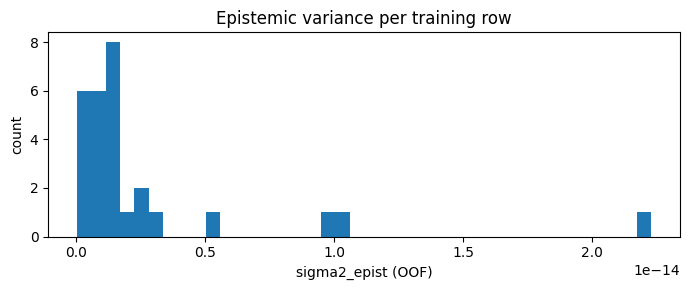

In [21]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Assesment comparing with lin

In [22]:
mu_recomputed_lin, sigma2_epist_oof_lin = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=False,
)

mu_diffs_lin = np.abs(mu_recomputed_lin - mu_oof)
mu_diffs_lin.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof_lin.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof_lin):.4f}")
# print(f"  max    = {sigma2_epist_oof_lin.max():.4f}")

count    28.000000
mean      4.826455
std       4.260144
min       0.103802
25%       1.371361
50%       4.119666
75%       6.370763
max      17.802589
Name: elongation_final, dtype: float64

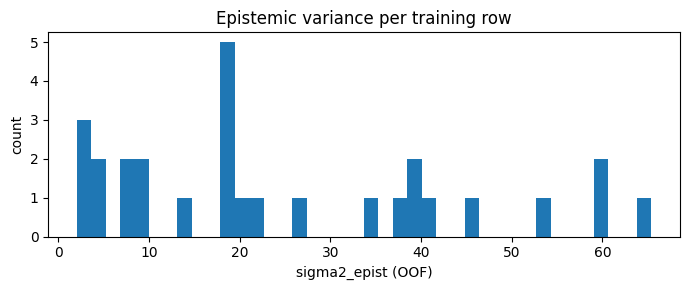

In [23]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof_lin, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Section 5 Conclusion
When number of lines is at least > 40 

Linear shows way more errors between the recomputed values. Weighted one is corrected.

# 6. Build Aleatoric Targets $\tilde r^2$

Each training row gets a noisy point-estimate of the aleatoric variance:

$$\tilde r_i^2 = \max\!\left((y_i - \hat\mu^{\text{OOF}}(\mathbf{x}_i))^2 - \hat\sigma^2_{\text{epist}}(\mathbf{x}_i),\;0\right).$$

Subtracting the epistemic component avoids double-counting it. Truncation at zero handles rows where the ensemble disagreement exceeds the squared residual.

In [24]:
r_tilde_sq, residuals_oof_arr, diag = modl.build_aleatoric_targets(
    y_true=df[TARGET].values,
    mu_oof=mu_oof.values,
    sigma2_epist_oof=sigma2_epist_oof,
)

print("=== Aleatoric target diagnostics ===")
for k, v in diag.items():
    print(f"  {k:20s} = {v}")

=== Aleatoric target diagnostics ===
  n_total              = 28
  n_truncated          = 0
  pct_truncated        = 0.0
  r_tilde_sq_min       = 0.0023610188840481085
  r_tilde_sq_max       = 1322.4299382150384
  r_tilde_sq_mean      = 59.32946028782822
  r_tilde_sq_median    = 4.568980971627914


In [25]:
r_tilde_sq

array([2.43449396e-01, 7.50974625e+01, 5.52128089e+00, 4.05890566e-01,
       2.86796701e+00, 6.51837809e-01, 4.25436950e+01, 8.01794489e+01,
       1.88992756e-01, 1.72418386e+00, 2.36101888e-03, 9.13607930e-01,
       1.81022073e+01, 1.26598213e+01, 2.51820956e+00, 5.51041168e-01,
       1.29431492e+01, 6.53061083e-01, 1.48000169e+01, 7.23119828e+00,
       2.74167193e-01, 5.85759943e+00, 2.14092883e-01, 4.52619652e+00,
       4.61176543e+00, 1.32242994e+03, 2.93003595e+01, 1.42118864e+01])

# 7. Train Model B — Aleatoric Variance Predictor

Model B is trained on $\log(\tilde r^2 + \epsilon)$ to keep the regression target well-conditioned (variances are non-negative and right-skewed). Inference back-transforms via $\exp$.

In [26]:
predictor_b = modl.fit_model_b(
    df=df,
    features=FEATURES,
    r_tilde_sq=r_tilde_sq,
    path=os.path.join(EXPERIMENT_DIR, "model_b"),
    presets=PRESETS_B,
    num_bag_folds=NUM_BAG_FOLDS_B,
    num_stack_levels=NUM_STACK_LEVELS_B,
    time_limit=TIME_LIMIT_B,
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       6.33 GB / 31.57 GB (20.1%)
Disk Space Avail:   737.42 GB / 932.08 GB (79.1%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_elongation\only-essays-v2-best-quality\model_b"
Train Data Rows:    28
Train Data Columns: 6
Label Column:       log_r_tilde_sq
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (7.187226186310301, -6.048238566298998

In [27]:
predictor_b.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-2.609386,root_mean_squared_error,0.089362,7.785606,0.000999,0.008000,2,True,10
1,XGBoost_BAG_L1,-2.648568,root_mean_squared_error,0.013011,0.756297,0.013011,0.756297,1,True,7
2,NeuralNetTorch_BAG_L1,-2.672942,root_mean_squared_error,0.029000,6.588179,0.029000,6.588179,1,True,8
3,CatBoost_BAG_L1,-2.743910,root_mean_squared_error,0.006005,1.965749,0.006005,1.965749,1,True,4
4,LightGBMLarge_BAG_L1,-2.768297,root_mean_squared_error,0.002999,1.284023,0.002999,1.284023,1,True,9
5,NeuralNetFastAI_BAG_L1,-2.806158,root_mean_squared_error,0.045162,7.108839,0.045162,7.108839,1,True,6
6,LightGBM_BAG_L1,-2.809715,root_mean_squared_error,0.002003,1.182658,0.002003,1.182658,1,True,2
7,LightGBMXT_BAG_L1,-2.809715,root_mean_squared_error,0.002998,1.308265,0.002998,1.308265,1,True,1
8,RandomForestMSE_BAG_L1,-2.880404,root_mean_squared_error,0.046351,0.433131,0.046351,0.433131,1,True,3
9,ExtraTreesMSE_BAG_L1,-2.955720,root_mean_squared_error,0.045521,0.448018,0.045521,0.448018,1,True,5


In [28]:
predictor_b.predict_oof()  

0     1.958002
1     1.363740
2    -0.096972
3     1.004661
4     0.145427
5     1.420295
6     0.427752
7     0.327401
8     0.081451
9     0.028358
10    0.843620
11    1.192089
12    0.933033
13    1.014258
14    1.066195
15    1.293688
16    0.782163
17    0.954277
18    0.919372
19    0.964020
20    1.079806
21    0.778847
22    1.027291
23    0.222868
24    1.282497
25    0.691401
26    1.961267
27    1.508772
Name: log_r_tilde_sq, dtype: float32

In [29]:
df_lado_a_lado = pd.DataFrame({
    "residual_oof": residuals_oof,
    "predict_random_error": predictor_b.predict_oof()  , 
    "epistemic_error": sigma2_epist_oof,
    f"{TARGET}": df[f"{TARGET}"],
    f"{TARGET}_final": df[TARGET]
}) 
df_lado_a_lado

,residual_oof,predict_random_error,epistemic_error,elongation_final,elongation_final_final
0,0.493406,1.958002,5.055369e-15,48.60,48.60
1,8.665879,1.363740,3.078758e-15,56.21,56.21
2,-2.349741,-0.096972,1.487207e-15,20.15,20.15
3,-0.637095,1.004661,1.261895e-15,22.04,22.04
4,1.693507,0.145427,1.606943e-15,24.62,24.62
5,-0.807365,1.420295,2.769988e-15,24.72,24.72
6,-6.522553,0.427752,1.880046e-15,27.43,27.43
7,-8.954298,0.327401,1.271535e-15,25.24,25.24
8,0.434733,0.081451,2.299111e-15,27.06,27.06
9,-1.313082,0.028358,1.595136e-15,26.17,26.17


# 8. Calibration Diagnostics

Test whether the central α-intervals produced by the predictive Gaussian actually contain the true $y$ on a fraction $\approx \alpha$ of OOF points.

- $\alpha$ here is the **nominal coverage** of an interval (between 0 and 1).
- Empirical coverage **below** nominal ⇒ overconfident (intervals too narrow).
- Empirical coverage **above** nominal ⇒ underconfident (intervals too wide).
- A scalar correction $\hat\sigma \mapsto c \cdot \hat\sigma$ pulls the worst level to nominal; we fit $c$ at $\alpha = 0.9$.

In [30]:
df[TARGET].var()

np.float64(182.1305037037037)

Real coverage considering sigmas calculated so far

Build the predictive distribution. Not totally OOF cause model b is not generating OOF preds, we assume it's optimistic just a bit too small to be considered.


In [31]:
variance_floor = VARIANCE_FLOOR_FRAC * df[TARGET].var()
sigma2_aleat_oof = modl.predict_aleatoric_variance(
    predictor_b, df[FEATURES], variance_floor=variance_floor,
)

sigma2_total_oof = sigma2_epist_oof + sigma2_aleat_oof
sigma_total_oof = np.sqrt(sigma2_total_oof)

y_true = df[TARGET].values
cal_before = modl.calibration_table(
    mu=mu_oof.values, sigma=sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("=== Calibration BEFORE recalibration ===")
cal_before

=== Calibration BEFORE recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.321429,-0.178571
1,0.80,0.500000,-0.300000
2,0.90,0.678571,-0.221429
3,0.95,0.750000,-0.200000


Fit a scalar recalibration factor to pull coverage using α=0.9 as nominal reference


In [32]:
c_opt = modl.fit_recalibration_scalar(
    mu=mu_oof.values,
    sigma=sigma_total_oof,
    y_true=y_true,
    target_alpha=RECALIBRATION_TARGET_ALPHA,
)
print(f"Recalibration scalar c = {c_opt:.4f}")

cal_after = modl.calibration_table(
    mu=mu_oof.values, sigma=c_opt * sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("\n=== Calibration AFTER recalibration ===")
cal_after

Recalibration scalar c = 1.8197

=== Calibration AFTER recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.500000,0.000000
1,0.80,0.785714,-0.014286
2,0.90,0.892857,-0.007143
3,0.95,0.928571,-0.021429


# 8.1 Validation Set Evaluation

Evaluate the freshly trained pair (A + B, with the recalibration $c$) on a
validation DataFrame.

`modl.predict_target` is target-agnostic: it accepts a DataFrame **or a dict**
and any AutoGluon predictor (IACS, UTS, Model B...), inferring the features
from the predictor when not given.

In [33]:
c_opt
weights

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.97533922e-17,
       0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 2.19504119e-17, 0.00000000e+00, 0.00000000e+00,
       2.75826247e-17])

In [34]:
len(base_model_names)
len(weights)

21

In [35]:
# ---- Validation set: df_schema (illustrative; in-sample, see caveat) ----
# df_val = df_schema.copy()

# Full calibrated predictive distribution on the validation set.
preds_val = modl.predict_with_uncertainty(
    X=df.copy(), # df_schema.copy()
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,
)

val_metrics = evla.metrics_on_dataframe(
    df=df.copy(), #df_schema.copy()
    target=TARGET,
    mu=preds_val["mu"].to_numpy(),
    sigma=preds_val["sigma_total"].to_numpy(),
    alphas=CALIBRATION_ALPHAS,
)
print("=== Validation metrics (df_schema) ===")
print({k: round(v, 4) for k, v in val_metrics.items() if k != "coverage"})
print("coverage:", {a: round(c, 3) for a, c in val_metrics["coverage"].items()})

=== Validation metrics (df_schema) ===
{'rmse': 6.3007, 'mae': 2.9975, 'mape': 17.8195, 'r2': 0.774}
coverage: {0.5: 0.571, 0.8: 0.964, 0.9: 0.964, 0.95: 0.964}


In [36]:
# # ---- Target-agnostic point prediction from a plain dict ----
# single = modl.predict_target(
#     predictor_a,
#     {"initial_diameter": 1.5, "purity": 99.9, "iacs": 88.26, "temperature": 623.0, "time": 60.0},
# )
# print(f"Predicted {TARGET}: {single[0]:.3f}")

# 9. Inference Example

Use the packaged `predict_with_uncertainty` to apply both models to new rows and return a full predictive distribution. The `recalibration_c` argument scales $\hat\sigma$ to match the calibration above.

In [37]:
df.head(5)

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final,is_essay,weight_col
0,2.160000,391.690000,99.9,4.90,573.0,30.0,48.60,True,1.0
1,2.182333,387.595254,99.9,6.02,573.0,30.0,56.21,True,1.0
2,1.200000,431.580000,99.9,0.94,523.0,30.0,20.15,True,1.0
3,1.200000,431.580000,99.9,0.94,523.0,60.0,22.04,True,1.0
4,1.200000,431.580000,99.9,0.94,523.0,90.0,24.62,True,1.0


In [38]:
# Fit the OOD reference on the training inputs (stored in artifacts later).
ood_ref = modl.fit_ood_reference(df, features=FEATURES)

preds = modl.predict_with_uncertainty(
    X=df.head(5),
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,          # physical ceiling -> mu_trunc / sigma_trunc / p_above_max
    ood_ref=ood_ref,      # inputs outside training cloud get inflated sigma
)
preds


,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,46.829376,5.288848e-16,2.315096,7.665695,2.768699,46.829376,1.0,46.829376,2.768699,0.0
1,53.198494,1.290150e-15,9.158225,30.324512,5.506770,53.198494,1.0,53.198494,5.506770,0.0
2,23.529531,1.628192e-15,2.131248,7.056940,2.656490,23.529531,1.0,23.529531,2.656490,0.0
3,24.352390,1.009678e-15,1.821305,6.030665,2.455741,24.352390,1.0,24.352390,2.455741,0.0
4,25.650723,8.198503e-16,2.090940,6.923474,2.631250,25.650723,1.0,25.650723,2.631250,0.0


# 10. Persist Artifacts

Save everything that the downstream stages (controller, propagation) will need.

In [39]:
# ---- Experiment artifacts (everything under EXPERIMENT_DIR / TAG) ----
artifacts_path = os.path.join(EXPERIMENT_DIR, "artifacts.pkl")

artifacts = {
    "features": FEATURES,
    "target": TARGET,
    "base_model_names": base_model_names,
    "weights": weights,
    "variance_floor": variance_floor,
    "recalibration_c": c_opt,
    "use_weighted_variance": USE_WEIGHTED_VARIANCE,
    "calibration_before": cal_before,
    "calibration_after": cal_after,
    "y_max": Y_MAX,
    "ood_ref": ood_ref,
}
with open(artifacts_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved to: {artifacts_path}")


Saved to: ../../models/annealing_elongation\only-essays-v2-best-quality\artifacts.pkl


In [40]:
# ---- Save global configuration (1.1) as YAML for this experiment (TAG) ----
global_config = {
    "TAG": TAG,
    "SCHEMA_DATE": SCHEMA_DATE,
    "varv.PATHS.data_raw": varv.PATHS.data_raw,
    "varv.PATHS.models": varv.PATHS.models,
    "FILE_NAME": FILE_NAME,
    "FILE_NAME_SCHEMA_DATA": FILE_NAME_SCHEMA_DATA,
    "PROCESS": PROCESS,
    "TARGET": TARGET,
    "FEATURES": FEATURES,
    "WEIGHT_ON_ESSAY_ROWS": WEIGHT_ON_ESSAY_ROWS,
    "PRESETS_A": PRESETS_A,
    "NUM_BAG_FOLDS_A": NUM_BAG_FOLDS_A,
    "NUM_BAG_SETS_A": NUM_BAG_SETS_A,
    "NUM_STACK_LEVELS_A": NUM_STACK_LEVELS_A,
    "TIME_LIMIT_A": TIME_LIMIT_A,
    "PRESETS_B": PRESETS_B,
    "NUM_BAG_FOLDS_B": NUM_BAG_FOLDS_B,
    "NUM_STACK_LEVELS_B": NUM_STACK_LEVELS_B,
    "TIME_LIMIT_B": TIME_LIMIT_B,
    "USE_WEIGHTED_VARIANCE": USE_WEIGHTED_VARIANCE,
    "VARIANCE_FLOOR_FRAC": VARIANCE_FLOOR_FRAC,
    "CALIBRATION_ALPHAS": list(CALIBRATION_ALPHAS),
    "RECALIBRATION_TARGET_ALPHA": RECALIBRATION_TARGET_ALPHA,
    "USE_SHARED_FOLDS": USE_SHARED_FOLDS,
    "FOLD_SEED": FOLD_SEED,
    "Y_MAX": Y_MAX,
}

config_path = os.path.join(EXPERIMENT_DIR, "global_config.txt")
with open(config_path, "w") as f:
    yaml.dump(global_config, f, default_flow_style=False, sort_keys=False)

print(f"Saved to: {config_path}")


Saved to: ../../models/annealing_elongation\only-essays-v2-best-quality\global_config.txt


In [41]:
# ---- OOF metrics: AutoGluon (Model A leader) vs H2O AutoML leader ----
# Both vectors are out-of-fold predictions; metrics are UNWEIGHTED on both
# sides, and with USE_SHARED_FOLDS=True the folds are identical -> coherent.
h2o_oof_preds = (
    aml_h2o.leader.cross_validation_holdout_predictions()
    .as_data_frame()
    .iloc[:, 0]
    .to_numpy()
)

metrics_agl = evla.one_step_metrics(y_true=y_true, mu=mu_oof.values)
metrics_h2o = evla.one_step_metrics(y_true=y_true, mu=h2o_oof_preds)

metrics_df = pd.DataFrame(
    [
        {"model": "AutoGluon (Model A, leader)", **metrics_agl},
        {"model": "H2O AutoML (leader)", **metrics_h2o},
    ]
)[["model", "rmse", "mae", "mape", "r2"]]

print(metrics_df)

# ---- Leaderboards from both engines ----
leaderboard_agl = predictor_a.leaderboard(silent=True)
leaderboard_h2o = aml_h2o.leaderboard.as_data_frame()

# ---- Save everything for this experiment (TAG) into separate CSV files ----
metrics_df.to_csv(os.path.join(EXPERIMENT_DIR, "metrics_comparison.csv"), index=False)
leaderboard_agl.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_autogluon.csv"), index=False)
leaderboard_h2o.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_h2o.csv"), index=False)

print(f"Saved to: {EXPERIMENT_DIR}")


                         model      rmse       mae       mape        r2
0  AutoGluon (Model A, leader)  7.702562  3.828200  21.889662  0.662183
1          H2O AutoML (leader)  9.172161  5.324016  25.581726  0.520979
Saved to: ../../models/annealing_elongation\only-essays-v2-best-quality


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


# 11. Load Artifacts & Predict (deployment simulation)

This section simulates a fresh process: it loads ONLY what was persisted in
Section 10 (`artifacts.pkl`) plus the two AutoGluon predictors from disk —
no variable from the training session above is reused. This is exactly what a
deployment script (or the MBC controller) would do. The same
`predict_with_uncertainty` call as Section 9 runs, but every ingredient
(`weights`, `recalibration_c`, `ood_ref`, `y_max`, ...) comes from the
reloaded artifacts, proving the persisted bundle is self-contained.

In [42]:

# ---- 1) Load the persisted artifact bundle (Section 10) ----
loaded_artifacts = load.load_pickle(EXPERIMENT_DIR, "artifacts.pkl")

# ---- 2) Reload both AutoGluon predictors from their TAG subfolders ----
predictor_a_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_a")
)
predictor_b_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_b")
)

print("Loaded artifacts keys:", list(loaded_artifacts.keys()))
print("Target:", loaded_artifacts["target"])
print("Features:", loaded_artifacts["features"])

Loaded artifacts keys: ['features', 'target', 'base_model_names', 'weights', 'variance_floor', 'recalibration_c', 'use_weighted_variance', 'calibration_before', 'calibration_after', 'y_max', 'ood_ref']
Target: elongation_final
Features: ['initial_diameter', 'tensile_strength', 'purity', 'elongation', 'temperature', 'time']


In [43]:
# ---- 3) Predict using ONLY the reloaded objects ----
# Build a small query frame (here: first rows of df, but in deployment this
# would be a brand-new candidate route from the controller).
X_query = df.head(5)

preds_loaded = modl.predict_with_uncertainty(
    X=X_query,
    predictor_a=predictor_a_loaded,
    predictor_b=predictor_b_loaded,
    weights=loaded_artifacts["weights"],
    model_names=loaded_artifacts["base_model_names"],
    features=loaded_artifacts["features"],
    variance_floor=loaded_artifacts["variance_floor"],
    recalibration_c=loaded_artifacts["recalibration_c"],
    use_weights=loaded_artifacts["use_weighted_variance"],
    y_max=loaded_artifacts["y_max"],
    ood_ref=loaded_artifacts["ood_ref"],
)
preds_loaded

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,46.829376,5.288848e-16,2.315096,7.665695,2.768699,46.829376,1.0,46.829376,2.768699,0.0
1,53.198494,1.290150e-15,9.158225,30.324512,5.506770,53.198494,1.0,53.198494,5.506770,0.0
2,23.529531,1.628192e-15,2.131248,7.056940,2.656490,23.529531,1.0,23.529531,2.656490,0.0
3,24.352390,1.009678e-15,1.821305,6.030665,2.455741,24.352390,1.0,24.352390,2.455741,0.0
4,25.650723,8.198503e-16,2.090940,6.923474,2.631250,25.650723,1.0,25.650723,2.631250,0.0


In [44]:
# # ---- 4) Target-agnostic quick prediction from a plain dict ----
# # Works for any predictor/target via modl.predict_target (features inferred
# # from the predictor when not passed explicitly).
# single_loaded = modl.predict_target(
#     predictor_a_loaded,
#     {"initial_diameter": 1.5, "purity": 99.9, "iacs": 88.26, "temperature": 623.0, "time": 60.0},
#     features=loaded_artifacts["features"],
# )
# print(f"Predicted {loaded_artifacts['target']}: {single_loaded[0]:.3f}")

In [45]:
# ---- 5) Sanity check: reloaded predictions match the in-session ones ----
# (Section 9 computed `preds` on df.head(5) with the same ood_ref/c_opt.)
import numpy as np
if "preds" in dir():
    max_mu_diff = float(np.abs(preds["mu"].to_numpy()
                               - preds_loaded["mu"].to_numpy()).max())
    max_sigma_diff = float(np.abs(preds["sigma_total"].to_numpy()
                                  - preds_loaded["sigma_total"].to_numpy()).max())
    print(f"max |mu diff|    = {max_mu_diff:.2e}")
    print(f"max |sigma diff| = {max_sigma_diff:.2e}")
    print("OK: artifacts reproduce the in-session pipeline."
          if max(max_mu_diff, max_sigma_diff) < 1e-8
          else "WARNING: mismatch - check that Section 9 used the same ood_ref.")
else:
    print("Run Section 9 first to enable the sanity check.")

max |mu diff|    = 0.00e+00
max |sigma diff| = 0.00e+00
OK: artifacts reproduce the in-session pipeline.
